# Análisis de Estacionalidad y Patrones Temporales

Este notebook resuelve el Issue #20 realizando un análisis detallado mediante series de tiempo, apoyado por la nueva arquitectura en base DuckDB que preserva las fechas completas.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='whitegrid', context='notebook')

# Conectar a la base
con = duckdb.connect('../datos/db/seguridad_convivencia.duckdb')

## 1. Patrones por Día de la Semana

C:\Users\user\AppData\Local\Temp\ipykernel_9392\2967477652.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dias, x='nombre_dia', y='total_delitos', palette='viridis')


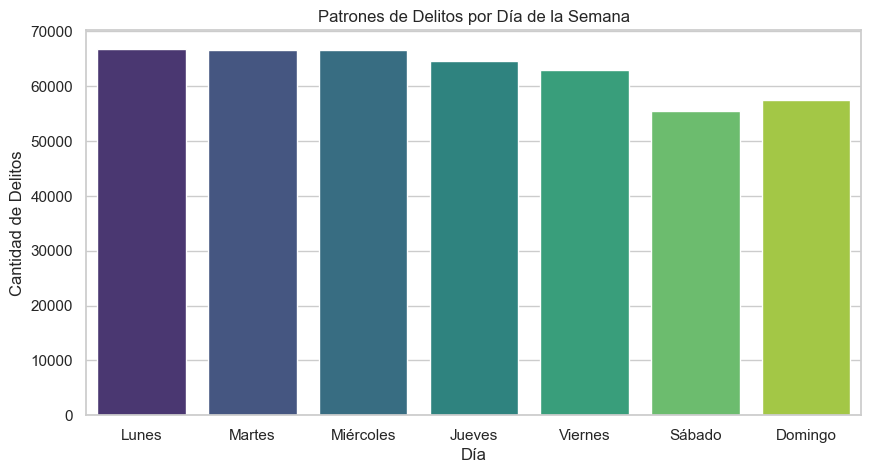

In [2]:
query_dias = """
SELECT 
    d.dia_semana, 
    SUM(f.cantidad) as total_delitos
FROM fact_delitos f
JOIN dim_fecha d USING(fecha_key)
WHERE d.dia_semana IS NOT NULL
GROUP BY d.dia_semana
ORDER BY d.dia_semana
"""
df_dias = con.execute(query_dias).fetchdf()
dias_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
df_dias['nombre_dia'] = df_dias['dia_semana'].map(dias_map)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_dias, x='nombre_dia', y='total_delitos', palette='viridis')
plt.title('Patrones de Delitos por Día de la Semana')
plt.ylabel('Cantidad de Delitos')
plt.xlabel('Día')
plt.show()

### 📌 *Hallazgo e Interpretación*
- **Concentración Inicial de la Semana:** Observamos que la mayor concentración de reportes se agrupa entre el lunes y el miércoles (superando los 66,000 incidentes en cada día a nivel histórico). 
- **Reducción en el Fin de Semana:** Curiosamente, los datos revelan una disminución perceptible los días sábado y domingo, los cuales tocan los puntos más bajos (cerca a 55,000 los sábados). Esto puede estar condicionado por la naturaleza de los delitos observados hasta ahora (ej. denuncias tramitadas en días hábiles ante la Fiscalía).

## 2. Comparativo Interanual por Meses

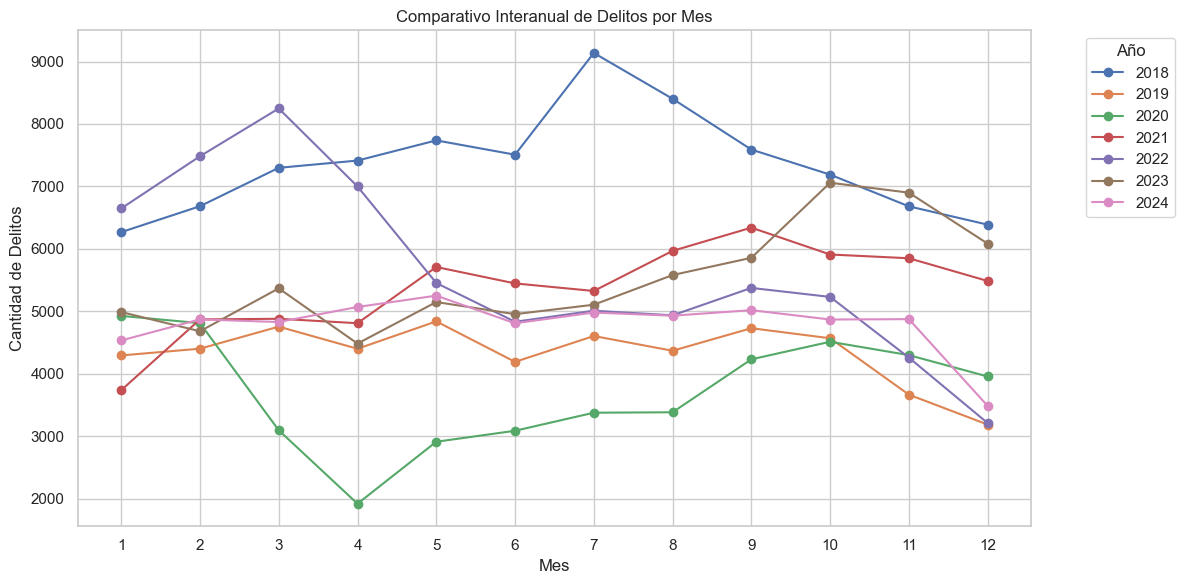

In [3]:
query_meses = """
SELECT 
    d.anio, 
    d.mes,
    SUM(f.cantidad) as total_delitos
FROM fact_delitos f
JOIN dim_fecha d USING(fecha_key)
WHERE d.mes IS NOT NULL AND d.anio IS NOT NULL
GROUP BY d.anio, d.mes
ORDER BY d.anio, d.mes
"""
df_meses = con.execute(query_meses).fetchdf()

plt.figure(figsize=(12, 6))
for anio in df_meses['anio'].unique():
    data_anio = df_meses[df_meses['anio'] == anio]
    plt.plot(data_anio['mes'], data_anio['total_delitos'], marker='o', label=str(anio))

plt.title('Comparativo Interanual de Delitos por Mes')
plt.ylabel('Cantidad de Delitos')
plt.xlabel('Mes')
plt.xticks(range(1, 13))
plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 📌 *Hallazgo e Interpretación*
- **Volumen atípico 2018:** Se aprecia que el año 2018 inicia con picos históricos extremadamente altos comparados al resto de años, con alta dispersión mensual.
- **Efecto Pandemia (2020):** Como es previsible, las curvas de 2020 muestran una fuerte depresión debido a las prolongadas cuarentenas de la pandemia por COVID-19.
- **Recuperación Pos-Pandemia (2021-2022):** Tras la reactivación social y económica en 2021, los incidentes delictivos volvieron a sus valores normales subyacentes, estabilizándose hacia ritmos estándar en las curvas de 2023 y 2024.

## 3. Descomposición Estacional (Tendencia, Estacionalidad y Residuos)

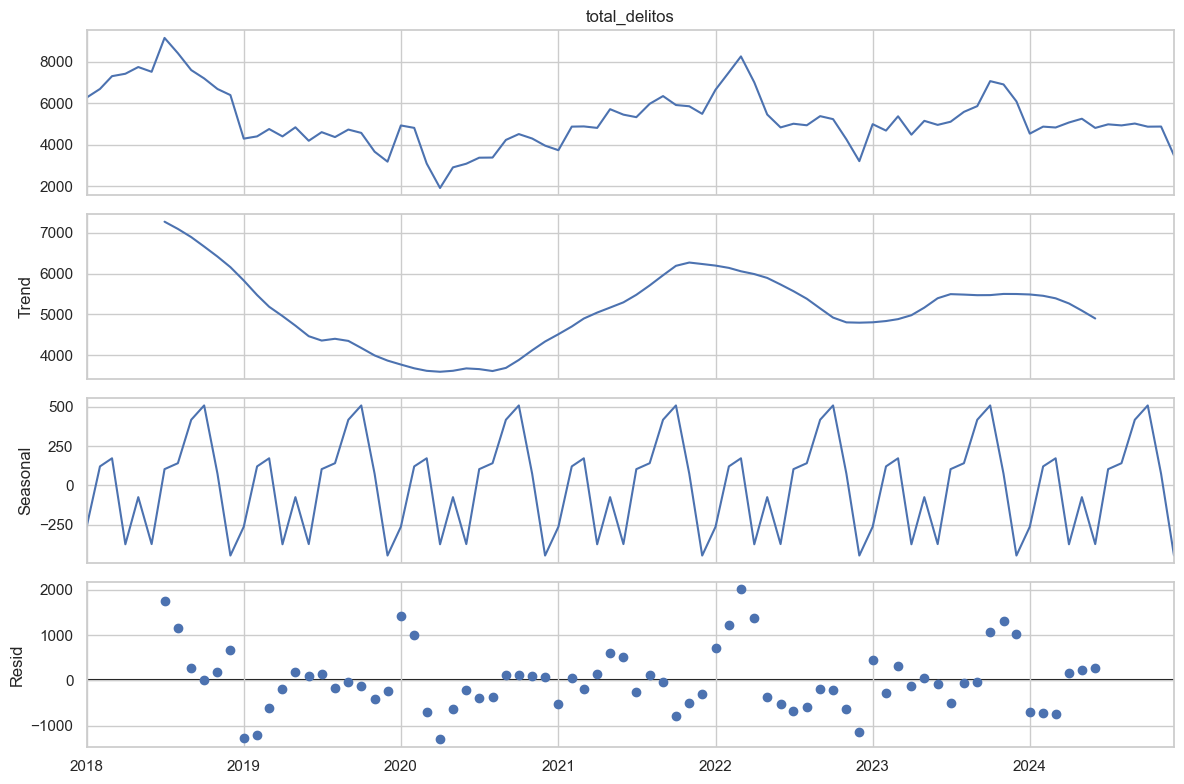

In [4]:
query_ts = """
SELECT 
    DATE_TRUNC('month', d.fecha) as fecha_mes,
    SUM(f.cantidad) as total_delitos
FROM fact_delitos f
JOIN dim_fecha d USING(fecha_key)
WHERE d.fecha IS NOT NULL
GROUP BY 1
ORDER BY 1
"""
df_ts = con.execute(query_ts).fetchdf()
df_ts['fecha_mes'] = pd.to_datetime(df_ts['fecha_mes'])
df_ts.set_index('fecha_mes', inplace=True)

# Descomposición estacional (usando modelo aditivo con período 12 - mensual)
if len(df_ts) >= 24:
    result = seasonal_decompose(df_ts['total_delitos'], model='additive', period=12)
    fig = result.plot()
    fig.set_size_inches(12, 8)
    plt.tight_layout()
    plt.show()
else:
    print(f'Insuficientes datos para descomposición estacional (meses disponibles: {len(df_ts)})')

### 📌 *Hallazgo e Interpretación*
- **Tendencia (`Trend`):** Al eliminar el 'ruido' mensual observamos el macro-comportamiento del país. Es drástico el evento anómalo de 2020 y la curva de crecimiento paulatino en el periodo de normalidad 2021-2023.
- **Factor Estacional (`Seasonal`):** Existe un patrón oscilatorio sistemático. Es muy llamativo descubrir que históricamente meses como **Septiembre y Octubre** son meses pico generalizados dentro del ciclo de la criminalidad anual colombiana.
- **Disminución Diciembre:** Notablemente, la tendencia estacional cae para Diciembre (alcanzando mínimos intermedios y reportando la cifra menor global de reportes directos en este corte). Este puede ser un fenómeno multifactorial donde las denuncias formales disminuyen temporalmente por fiestas, a pesar de la percepción que se pudiese tener.